# TCCT S89 - Blind Stop-Relocation Counterfactual Test

S89 keeps the S87D decoder, TCCT core, canonicalizer, propagation, undirected freeze behavior, observation aggregation, and deduplication mechanism unchanged. The only experimental novelty is a conserved stop-relocation intervention: restore the one factual Stop branch and move Stop to a distinct branch while preserving exactly one Stop.

The protocol and test definitions are hashed before case generation. There is no training, search, decoder editing, or retuning. Run once from a fresh kernel and preserve either success or failure. Expected workload: 512 worlds.


Dataset[{<|Stage -> S86, Name -> ExternalSixBranchBlind, CandidateFileLoaded -> True, 
 
>     CandidateHash -> a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     ExpectedCandidateHash -> 
 
>      a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     CandidateK -> 19, CandidatePolicyLength -> 26, 
 
>     OriginalFrozenModelChanged -> False, FrozenCandidateChanged -> False, 
 
>     CoreChanged -> False, PreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, CandidateFileLoaded, 
 
>      CandidateHash, ExpectedCandidateHash, CandidateK, CandidatePolicyLength, 
 
>      OriginalFrozenModelChanged, FrozenCandidateChanged, CoreChanged, PreflightPassed}\
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
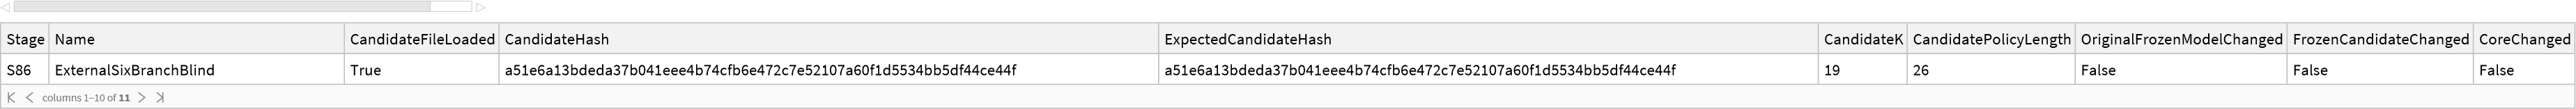

In [5]:
ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8661d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];


ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];


ClearAll[HierarchicalDiamondIn80,Case80];

HierarchicalDiamondIn80[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g,l1,l2,lg,r1,r2,rg,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g=next+2;
l1=next+3;
l2=next+4;
lg=next+5;
r1=next+6;
r2=next+7;
rg=next+8;
next=next+9;
added=Join[
added,
{
DirectedEdge[parent,l1],
DirectedEdge[parent,l2],
DirectedEdge[l1,lg],
DirectedEdge[l2,lg],
DirectedEdge[lg,s1],
DirectedEdge[parent,r1],
DirectedEdge[parent,r2],
DirectedEdge[r1,rg],
DirectedEdge[r2,rg],
DirectedEdge[rg,s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,removed],
added
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

Case80[
depth_Integer,
answer_Integer,
target_String
]:=HierarchicalDiamondIn80[
Case59[depth,answer,target]
];

topologySpec80=<|
"Topology"->"HierarchicalDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->
"OuterDiamondWhoseTwoUpperBranchesArePrivateDiamonds",
"CrossParentSharing"->False,
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"HierarchyLevels"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->9,
"ReplacementEdgesPerOriginalIncomingEdge"->13,
"EdgeDeltaPerOriginalIncomingEdge"->12,
"ExpectedCanonicalContractionsPerOriginalEdge"->3,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"PrimitivePrivateDiamondSeenBeforeS80"->True,
"HierarchicalCompositionSeenBeforeS80"->False,
"TopologyUsedBeforeS80"->False
|>;

topologySpecHash80=Hash[
Normal[topologySpec80],
"SHA256",
"HexString"
];

topologyImplementationHash80=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];

ClearAll[ChainIn63, SharedMerge63, Case63];
ChainIn63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, inc, rm, add, new, n},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
inc=Cases[
e,
DirectedEdge[u_, v_ ] /; MemberQ[f, v]:>{u, v}
];
rm=DirectedEdge@@@inc;
add=Flatten[
Table[
n=mx+i;
{
DirectedEdge[inc[[i, 1]], n],
DirectedEdge[n, inc[[i, 2]]]
},
{i, Length[inc]}
],
1
];
new=Union[
Join[
Complement[e, rm],
add
]
];
{{new, x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
SharedMerge63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, ps, rm, g, i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>u
];
rm=(DirectedEdge[#, m]&)/@ps;
new=Complement[
new,
rm
];
g=mx+i;
new=Join[
new,
(DirectedEdge[#, g]&)/@ps,
{DirectedEdge[g, m]}
],
{i, Length[f]}
];
{{Union[new], x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
Case63[
g_String ,
d_Integer,
a_Integer,
t_String
]:=
Switch[
g,
"ChainIn",
ChainIn63[Case59[d, a, t]],
"SharedMerge",
SharedMerge63[Case59[d, a, t]]
];

ClearAll[ParallelIn71];
ParallelIn71[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, incs, rm,
add, next, g1, g2, i, j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>{u, v}
];
rm=DirectedEdge@@@incs;
add= {};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[incs[[j, 1]], g1],
DirectedEdge[g1, m],
DirectedEdge[incs[[j, 1]], g2],
DirectedEdge[g2, m]
}
],
{j, Length[incs]}
];
new=Join[
Complement[new, rm],
add
],
{i, Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
}, a}
];

(* In[410] *)
ClearAll[Case71];
Case71[
d_Integer,
a_Integer,
t_String
]:=
ParallelIn71[
Case59[d, a, t]
];

ClearAll[ParallelOut72,SharedParallelIn72,Case72B];
ParallelOut72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,outs,rm,
add,g1,g2,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
outs=Cases[
new,
DirectedEdge[u_,v_]/;u===m:>{u,v}
];
rm=DirectedEdge@@@outs;
add={};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[m,g1],
DirectedEdge[g1,outs[[j,2]]],
DirectedEdge[m,g2],
DirectedEdge[g2,outs[[j,2]]]
}
],
{j,Length[outs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

SharedParallelIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,ps,rm,
g1,g2,add,i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>u
];
rm=(DirectedEdge[#,m]&)/@ps;
g1=next;
g2=next+1;
next=next+2;
add=Join[
Flatten[
Table[
{
DirectedEdge[ps[[j]],g1],
DirectedEdge[ps[[j]],g2]
},
{j,Length[ps]}
],
1
],
{
DirectedEdge[g1,m],
DirectedEdge[g2,m]
}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

Case72B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"ParallelOut",
ParallelOut72[Case59[depth,answer,target]],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"SharedParallelIn",
SharedParallelIn72[Case59[depth,answer,target]],
_,
$Failed
];



ClearAll[
EdgeSet81,
VertexSet81,
WithEdges81,
EdgePatch81,
ApplyEdgePatch81,
InverseEdgePatch81,
VertexDegreeProfile81,
OppositeAction81
];

EdgeSet81[c_List]:=c[[1,1]];

VertexSet81[c_List]:=Union@Flatten[
List@@@EdgeSet81[c]
];

WithEdges81[c_List,newEdges_List]:=Module[
{x=c[[1]],a=c[[2]]},
{{
Union[newEdges],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

EdgePatch81[from_List,to_List]:=<|
"Remove"->Complement[
EdgeSet81[from],
EdgeSet81[to]
],
"Add"->Complement[
EdgeSet81[to],
EdgeSet81[from]
]
|>;

ApplyEdgePatch81[c_List,patch_Association]:=Module[
{e,remove,add,valid},
e=EdgeSet81[c];
remove=patch["Remove"];
add=patch["Add"];
valid=And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
];
If[
!TrueQ[valid],
Return[$Failed]
];
WithEdges81[
c,
Join[Complement[e,remove],add]
]
];

InverseEdgePatch81[patch_Association]:=<|
"Remove"->patch["Add"],
"Add"->patch["Remove"]
|>;

VertexDegreeProfile81[c_List]:=Module[
{e=EdgeSet81[c],vertices},
vertices=VertexSet81[c];
AssociationThread[
vertices,
Map[
Function[node,
{
Count[e,DirectedEdge[_,node]],
Count[e,DirectedEdge[node,_]]
}
],
vertices
]
]
];

OppositeAction81[action_String]:=Switch[
action,
"Continue","Stop",
"Stop","Continue",
_,Missing["UnknownAction"]
];ClearAll[
LocalMediatorSources82,
FullSemanticPatch82,
LocalMediatorPatch82,
PatchSourceSet82,
ReferenceAction82
];

LocalMediatorSources82[c_List]:=Module[
{x=c[[1]],answer=c[[2]],m},
m=x[[6,answer]];
{m,m+1,m+2}
];

FullSemanticPatch82[
depth_Integer,
answer_Integer
]:=EdgePatch81[
Case59[depth,answer,"Continue"],
Case59[depth,answer,"Stop"]
];

LocalMediatorPatch82[
depth_Integer,
answer_Integer
]:=Module[
{factual,fullPatch,sources},
factual=Case59[depth,answer,"Continue"];
fullPatch=FullSemanticPatch82[depth,answer];
sources=LocalMediatorSources82[factual];
<|
"Remove"->Select[
fullPatch["Remove"],
MemberQ[sources,#[[1]]]&
],
"Add"->Select[
fullPatch["Add"],
MemberQ[sources,#[[1]]]&
]
|>
];

PatchSourceSet82[patch_Association]:=Union[
Map[First,patch["Remove"]],
Map[First,patch["Add"]]
];

ReferenceAction82[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],e,m,safe,u,dum,
correct,wrong,continueEdges,stopEdges
},
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dum=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dum]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],
"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],
"Stop",
True,
"Undefined"
]
];

interventionImplementationHash82=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];expectedMinimalKernelDefinitionTextHash86=
"d56be85db649ba1ea4118050a019d35a07c28f394396858f1d40a1f90572b922";
expectedCanonicalizerHash86=
"5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d";
expectedStableFrozenArchitectureHash86=
"d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d";
expectedInterventionHash86=
"45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf";
expectedCandidateHash86=
"a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f";

candidateSnapshotPath86=
"E:/engine_wolf/TCCT_S83B_FrozenCandidate.wl";

If[
!FileExistsQ[candidateSnapshotPath86],
Print["S86 aborted: frozen S83B candidate file is missing."];
Abort[]
];

Get[candidateSnapshotPath86];

ClearAll[CoreDefinitionBundle86];
CoreDefinitionBundle86[]:={
DownValues[P59],DownValues[A59],DownValues[T59],DownValues[Case59],
OwnValues[rw60],DownValues[Pack60],DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],DownValues[EncodeRows75],
DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],DownValues[Case79]
};

minimalKernelDefinitionTextHash86=Hash[
ToString[InputForm[CoreDefinitionBundle86[]]],
"SHA256","HexString"
];

stableFrozenArchitectureHash86=Hash[
{
Normal[frozen75D],
minimalKernelDefinitionTextHash86,
canonicalizerImplementationHash79B
},
"SHA256","HexString"
];

candidateHashLoaded86=If[
AssociationQ[frozenCandidate83B],
Hash[Normal[frozenCandidate83B],"SHA256","HexString"],
Missing["CandidateNotLoaded"]
];

preflightPassed86=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[
minimalKernelDefinitionTextHash86,
expectedMinimalKernelDefinitionTextHash86
],
SameQ[
canonicalizerImplementationHash79B,
expectedCanonicalizerHash86
],
SameQ[
stableFrozenArchitectureHash86,
expectedStableFrozenArchitectureHash86
],
SameQ[interventionImplementationHash82,expectedInterventionHash86],
AssociationQ[frozenCandidate83B],
SameQ[candidateHashLoaded86,expectedCandidateHash86],
SameQ[frozenCandidate83B["BaseFrozenModelHash"],expectedFrozenModelHash79A],
SameQ[frozenCandidate83B["EncoderParams"],frozen75D["Params"]],
SameQ[frozenCandidate83B["Representation"],"KExactRole"],
SameQ[frozenCandidate83B["K"],19],
SameQ[Length[frozenCandidate83B["Policy"]],26],
SameQ[frozenCandidate83B["DevelopmentScore"],264],
TrueQ[frozenCandidate83B["ExactNodeRoleUsed"]],
TrueQ[frozenCandidate83B["FrozenBeforeS84"]]
];

preflight86=<|
"Stage"->"S86",
"Name"->"ExternalSixBranchBlind",
"CandidateFileLoaded"->FileExistsQ[candidateSnapshotPath86],
"CandidateHash"->candidateHashLoaded86,
"ExpectedCandidateHash"->expectedCandidateHash86,
"CandidateK"->If[AssociationQ[frozenCandidate83B],frozenCandidate83B["K"],Missing[]],
"CandidatePolicyLength"->If[
AssociationQ[frozenCandidate83B],Length[frozenCandidate83B["Policy"]],Missing[]
],
"OriginalFrozenModelChanged"->False,
"FrozenCandidateChanged"->False,
"CoreChanged"->False,
"PreflightPassed"->preflightPassed86
|>;

If[
!TrueQ[preflightPassed86],
Print[Dataset[{preflight86}]];
Print["S86 aborted: frozen architecture or S83B candidate mismatch."];
Abort[]
];

Dataset[{preflight86}]


Dataset[{<|Stage -> S89, Name -> StopRelocationCounterfactualBlind, 
 
>     CandidateFrozenBeforeProtocol -> True, 
 
>     DecoderCandidateHash -> 
 
>      703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     DecoderCandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, 
 
>     FeatureRuntimeFileHash -> 
 
>      7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee, 
 
>     K33CandidateHash -> 
 
>      2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4, 
 
>     FeatureFamily -> QueriedGlobalMoments, FeatureDimension -> 27, BranchCount -> 8, 
 
>     Depths -> {61, 109}, TrainingRun -> False, CandidateSearchRun -> False, 
 
>     DecoderEditApplied -> False, RetuningApplied -> False, 
 
>     S88CheckpointLocked -> True, S89ResultAlreadyPresent -> False, 
 
>     PreflightPassed -> True|>}, TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[
 
>      String], TypeSystem`AnyType, 18], 1], <||>]
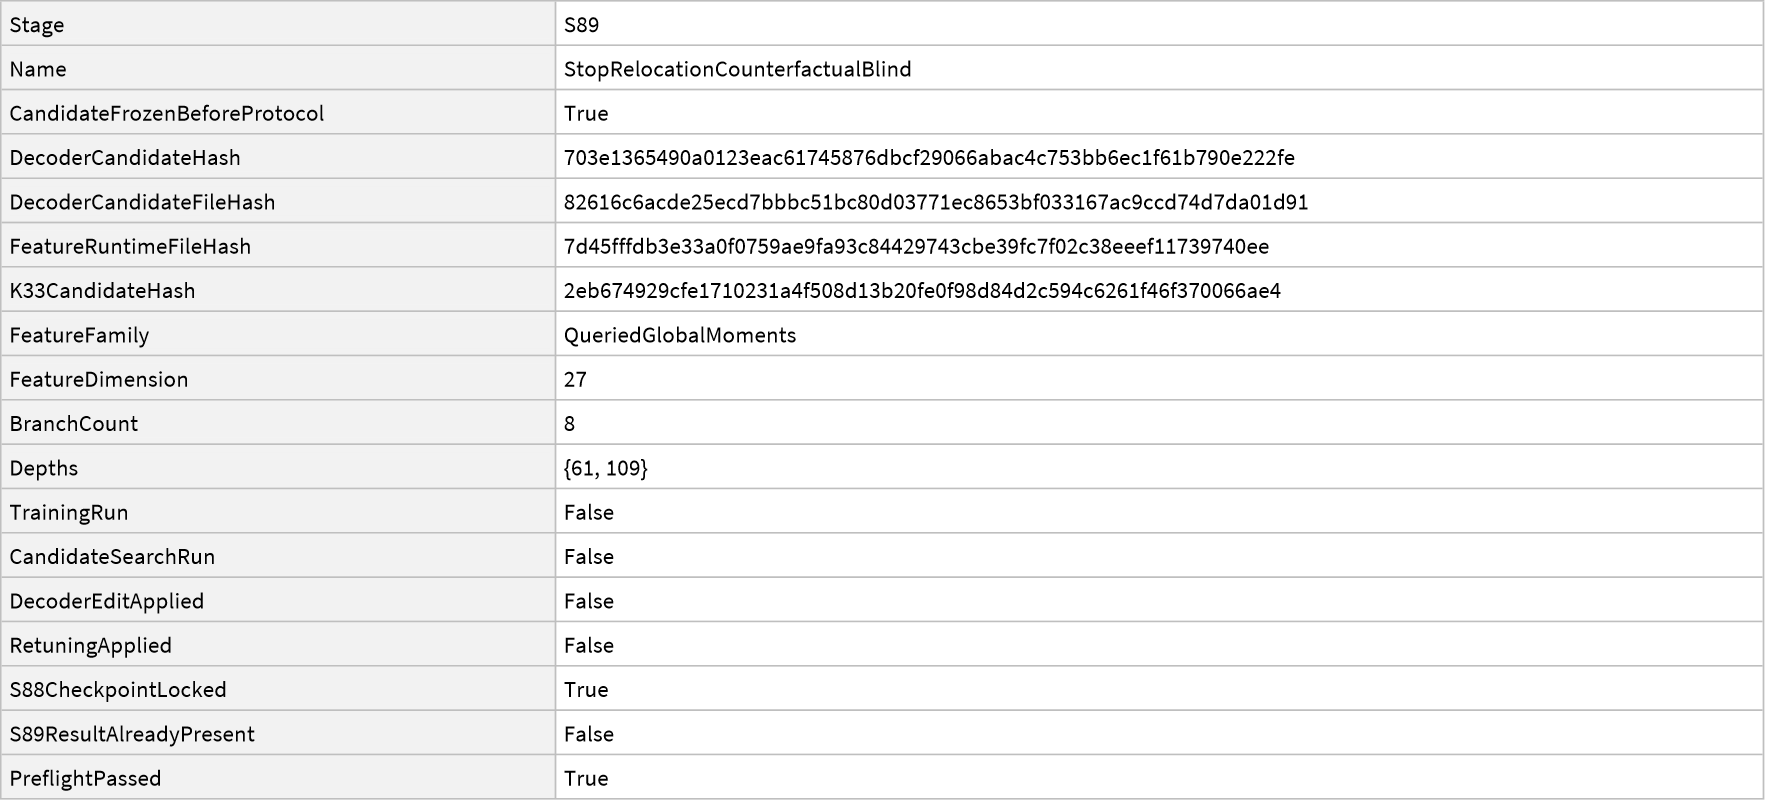

In [89]:
expectedFrozenModelHash89=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedK33CandidateHash89=
"2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4";
expectedK33CandidateFileHash89=
"4a252b8977101d024b1b2feb00b4626ca28290c3982cdad199bc78ef7e0c98f1";
expectedDecoderCandidateHash89=
"703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe";
expectedDecoderCandidateFileHash89=
"82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91";
expectedClassifierBinaryHash89=
"2b8861c03c8169571061a85c12644c6e30a11e8f8f15f5c69c6761215f4752f1";
expectedFeatureRuntimeFileHash89=
"7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee";
expectedFreezeProtocolHash89=
"03d7a40eefdaec9d9fce599517d3663ba381d50218bfe4934580bd22ca31b86c";
expectedFreezeCertificateFileHash89=
"7c83717fc5bf50b1bde853401da8d0fc5931d6b1b23663d75777e1e45516fb8e";
expectedS88CheckpointFileHash89=
"1c56bb0a87eba871f8474a93d4206d6aebbf1d66412a0d3927e62155a81e2fa4";

k33CandidatePath89="E:/engine_wolf/TCCT_S86E_K33FrozenCandidate.wl";
decoderRuntimePath89="E:/engine_wolf/TCCT_S87D_FrozenDecoderRuntime.wl";
decoderCandidatePath89=
"E:/engine_wolf/TCCT_S87D_FrozenWorldMultisetDecoder.wxf";
freezeCertificatePath89="E:/engine_wolf/TCCT_S87D_FreezeCertificate.json";
s88CheckpointPath89="E:/engine_wolf/TCCT_S88_BlindResultCertificate.json";
s89ResultCertificatePath=
"E:/engine_wolf/TCCT_S89_BlindResultCertificate.json";

ClearAll[FileSHA256Hex89];
FileSHA256Hex89[path_String]:=If[
FileExistsQ[path],
IntegerString[FileHash[path,"SHA256"],16,64],
Missing["FileMissing",path]
];

requiredFilesPresent89=And@@Map[
FileExistsQ,
{
k33CandidatePath89,decoderRuntimePath89,
decoderCandidatePath89,freezeCertificatePath89,s88CheckpointPath89
}
];

If[
!TrueQ[requiredFilesPresent89],
Print["S89 aborted: one or more frozen input files are missing."];
Abort[]
];

If[
FileExistsQ[s89ResultCertificatePath],
Print["S89 aborted: a prior S89 result certificate already exists."];
Print["Preserve the prior blind result; do not overwrite or retune."];
Abort[]
];

k33CandidateFileHashBefore89=FileSHA256Hex89[k33CandidatePath89];
decoderRuntimeFileHashBefore89=FileSHA256Hex89[decoderRuntimePath89];
decoderCandidateFileHashBefore89=FileSHA256Hex89[decoderCandidatePath89];
freezeCertificateFileHashBefore89=FileSHA256Hex89[freezeCertificatePath89];
s88CheckpointFileHashBefore89=FileSHA256Hex89[s88CheckpointPath89];

Clear[frozenCandidate86E];
Get[k33CandidatePath89];
k33CandidateHashLoaded89=If[
AssociationQ[frozenCandidate86E],
Hash[Normal[frozenCandidate86E],"SHA256","HexString"],
Missing["K33CandidateNotLoaded"]
];

Get[decoderRuntimePath89];
frozenDecoderLoaded89=TCCTLoadFrozenDecoderS87D[decoderCandidatePath89];
frozenDecoderRaw89=If[
AssociationQ[frozenDecoderLoaded89],
KeyDrop[frozenDecoderLoaded89,{"Classifier"}],
$Failed
];
decoderCandidateHashLoaded89=If[
AssociationQ[frozenDecoderRaw89],
Lookup[frozenDecoderRaw89,"CandidateHash",Missing["CandidateHashMissing"]],
Missing["DecoderNotLoaded"]
];
decoderPayloadHashLoaded89=If[
AssociationQ[frozenDecoderRaw89],
Hash[
Normal[KeyDrop[frozenDecoderRaw89,{"CandidateHash"}]],
"SHA256","HexString"
],
Missing["DecoderNotLoaded"]
];

freezeCertificate89=Quiet@Check[
Import[freezeCertificatePath89,"RawJSON"],
$Failed
];

s88Checkpoint89=Quiet@Check[
Import[s88CheckpointPath89,"RawJSON"],
$Failed
];

ClearAll[CoreDefinitionBundle89];
CoreDefinitionBundle89[]:=CoreDefinitionBundle86[];

modelHashBefore89=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashBefore89=Hash[
Normal[frozenCandidate86E],"SHA256","HexString"
];
decoderObjectHashBefore89=If[
AssociationQ[frozenDecoderRaw89],
Hash[Normal[frozenDecoderRaw89],"SHA256","HexString"],
Missing["DecoderNotLoaded"]
];
coreHashBefore89=Hash[CoreDefinitionBundle89[],"SHA256","HexString"];
canonicalizerHashBefore89=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256","HexString"
];
interventionHashBefore89=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256","HexString"
];
topologyPrimitiveHashBefore89=Hash[
{
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[HierarchicalDiamondIn80]
},
"SHA256","HexString"
];
decoderRuntimeDefinitionHashBefore89=Hash[
TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"
];

preflightPassed89=And[
TrueQ[preflightPassed86],
SameQ[modelHashBefore89,expectedFrozenModelHash89],
AssociationQ[frozenCandidate86E],
SameQ[k33CandidateHashLoaded89,expectedK33CandidateHash89],
SameQ[k33CandidateFileHashBefore89,expectedK33CandidateFileHash89],
SameQ[frozenCandidate86E["K"],33],
SameQ[frozenCandidate86E["Representation"],"KExactRole"],
AssociationQ[frozenDecoderLoaded89],
AssociationQ[frozenDecoderRaw89],
Head[frozenDecoderLoaded89["Classifier"]]===ClassifierFunction,
SameQ[decoderCandidateHashLoaded89,expectedDecoderCandidateHash89],
SameQ[decoderPayloadHashLoaded89,expectedDecoderCandidateHash89],
SameQ[decoderCandidateFileHashBefore89,expectedDecoderCandidateFileHash89],
SameQ[decoderRuntimeFileHashBefore89,expectedFeatureRuntimeFileHash89],
SameQ[frozenDecoderRaw89["ClassifierBinaryHash"],
expectedClassifierBinaryHash89],
SameQ[frozenDecoderRaw89["FeatureRuntimeFileHash"],
FileHash[decoderRuntimePath89,"SHA256"]],
SameQ[frozenDecoderRaw89["ProtocolHash"],expectedFreezeProtocolHash89],
SameQ[frozenDecoderRaw89["FeatureFamily"],"QueriedGlobalMoments"],
SameQ[frozenDecoderRaw89["FeatureDimension"],27],
SameQ[Length[frozenDecoderRaw89["FeatureNames"]],27],
SameQ[frozenDecoderRaw89["K"],33],
SameQ[frozenDecoderRaw89["BaseFrozenModelHash"],
expectedFrozenModelHash89],
SameQ[frozenDecoderRaw89["BaseK33CandidateHash"],
expectedK33CandidateHash89],
TrueQ[frozenDecoderRaw89["FrozenBeforeS88"]],
TrueQ[frozenDecoderRaw89["S88DataReadBeforeFreeze"]===False],
AssociationQ[freezeCertificate89],
SameQ[freezeCertificateFileHashBefore89,
expectedFreezeCertificateFileHash89],
TrueQ[freezeCertificate89["FreezeValidityPassed"]],
TrueQ[freezeCertificate89["ReadyForS88"]],
SameQ[freezeCertificate89["CandidateHash"],
expectedDecoderCandidateHash89],
SameQ[freezeCertificate89["Outcome"],
"S87D_DECODER_FROZEN_AND_LOCKED_READY_FOR_S88"],
TrueQ[freezeCertificate89["CoreChanged"]===False],
TrueQ[freezeCertificate89["S88DataReadBeforeFreeze"]===False],
AssociationQ[s88Checkpoint89],
SameQ[s88CheckpointFileHashBefore89,expectedS88CheckpointFileHash89],
SameQ[s88Checkpoint89["Stage"],"S88"],
TrueQ[s88Checkpoint89["TestValidityPassed"]],
TrueQ[s88Checkpoint89["BlindPerfect"]],
SameQ[s88Checkpoint89["Outcome"],
"S88_BLIND_EIGHT_BRANCH_FROZEN_DECODER_PASS"],
!FileExistsQ[s89ResultCertificatePath]
];

preflight89=<|
"Stage"->"S89",
"Name"->"StopRelocationCounterfactualBlind",
"CandidateFrozenBeforeProtocol"->True,
"DecoderCandidateHash"->decoderCandidateHashLoaded89,
"DecoderCandidateFileHash"->decoderCandidateFileHashBefore89,
"FeatureRuntimeFileHash"->decoderRuntimeFileHashBefore89,
"K33CandidateHash"->k33CandidateHashLoaded89,
"FeatureFamily"->If[
AssociationQ[frozenDecoderRaw89],
frozenDecoderRaw89["FeatureFamily"],Missing[]
],
"FeatureDimension"->If[
AssociationQ[frozenDecoderRaw89],
frozenDecoderRaw89["FeatureDimension"],Missing[]
],
"BranchCount"->8,
"Depths"->{61,109},
"TrainingRun"->False,
"CandidateSearchRun"->False,
"DecoderEditApplied"->False,
"RetuningApplied"->False,
"S88CheckpointLocked"->And[
SameQ[s88CheckpointFileHashBefore89,expectedS88CheckpointFileHash89],
TrueQ[s88Checkpoint89["BlindPerfect"]]
],
"S89ResultAlreadyPresent"->FileExistsQ[s89ResultCertificatePath],
"PreflightPassed"->preflightPassed89
|>;

If[
!TrueQ[preflightPassed89],
Print[Dataset[{preflight89}]];
Print["S89 aborted: frozen decoder, architecture, or file lock mismatch."];
Abort[]
];

Dataset[{preflight89}]


Dataset[{<|Stage -> S89, Name -> StopRelocationCounterfactualBlind, 
 
>     Candidate -> S87D-FrozenWorldMultisetDecoder, 
 
>     CandidateHash -> 703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     CandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, 
 
>     FeatureRuntimeFileHash -> 
 
>      7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee, 
 
>     K33CandidateHash -> 
 
>      2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4, 
 
>     S88CheckpointFileHash -> 
 
>      1c56bb0a87eba871f8474a93d4206d6aebbf1d66412a0d3927e62155a81e2fa4, 
 
>     BranchCount -> 8, Depths -> {61, 109}, 
 
>     Topologies -> {TripleSerialDiamondIn, HierarchicalTerminalDiamondIn}, 
 
>     TopologySpecHash -> 
 
>      0f7a7a0ae0fb0342d64f57a7a4345cac3d296ee00badb494b70af408d265abfe, 
 
>     RelocationPairs -> 
 
>      {{1, 5}, {2, 6}, {3, 7}, {4, 8}, {5, 1}, {6, 2}, {7, 3}, {8, 4}}, 
 
>     ExpectedScenarios -> 32, ExpectedWorldPairs -> 256, ExpectedWorlds -> 512, 
 
>     ExpectedBaselineContinueWorlds -> 224, ExpectedBaselineStopWorlds -> 32, 
 
>     ExpectedCounterfactualContinueWorlds -> 224, 
 
>     ExpectedCounterfactualStopWorlds -> 32, ExpectedRelocatedFromPairs -> 32, 
 
>     ExpectedRelocatedToPairs -> 32, ExpectedUnaffectedPairs -> 192, 
 
>     ExternalGrammar -> IndependentEightBranchT89, 
 
>     Intervention -> ConservedSingleStopRelocation, 
 
>     InterventionSemantics -> 
 
>      RestoreFormerStopBranchAndStopDistinctFormerContinueBranch, 
 
>     ConservationLaw -> ExactlyOneStopBeforeAndAfter, 
 
>     QueryGrid -> AllEightQueriesBeforeAndAfterRelocation, 
 
>     FeatureFamily -> QueriedGlobalMoments, FeatureDimension -> 27, 
 
>     ObservationAggregation -> FullQueriedObservationMultisetWithoutCodeDeduplication, 
 
>     LegacyTokenDeduplication -> DeleteDuplicatesAfterExactRoleCodePairing, 
 
>     SuccessCriterion -> 
 
>      ValidHarnessAndAll512WorldsCorrectIncludingBothDirectionsAndUnaffectedQueries, 
 
>     CandidateFrozenBeforeProtocol -> True, S88CheckpointReadOnlyLock -> True, 
 
>     S88PredictionsUsedForSelection -> False, TrainingRun -> False, 
 
>     CandidateSearchRun -> False, DecoderEditApplied -> False, 
 
>     RetuningApplied -> False, NoCaseEvaluatedBeforeProtocolHash -> True, 
 
>     ProtocolHash -> 32f425daed5c9604a2971de24b763360b14f0c64cddd3e08fc0d1cfa9de9b846, 
 
>     TestDefinitionHash -> 
 
>      c78b29923c011330697a70e628f5c53410c5c46dcb0cd36908002a008f8fd7f5|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 43], 
 
>    1], <||>]
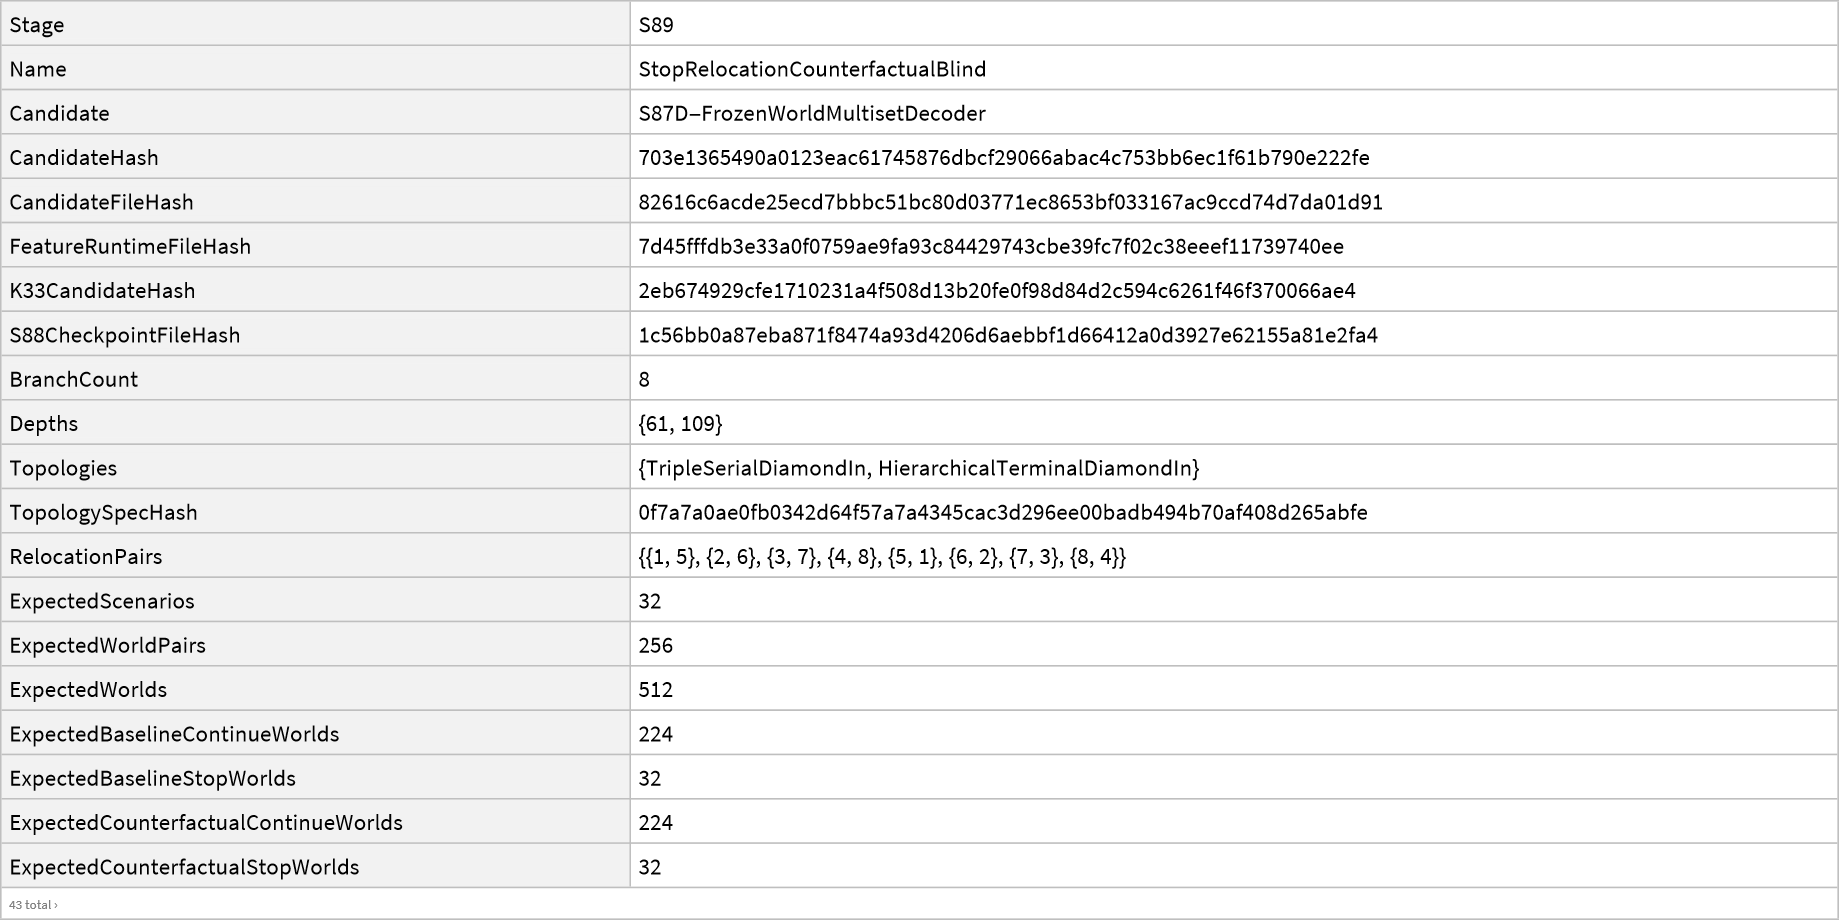

In [139]:
ClearAll[
T89,
Case89,
ReferenceAction89,
NodeRole89,
EncodePair89,
LegacyPredictTokens89,
PredictFrozenDecoder89,
TripleSerialDiamondIn89,
HierarchicalTerminalDiamondIn89,
SetAnswer89,
TopologyTransform89,
ExpectedContractions89,
BranchStopPatch89,
BranchContinuePatch89,
StopRelocationPatch89,
PrepareWorld89,
PrepareScenario89,
S89TestDefinitionBundle
];


T89[
depth_Integer,
target_String,
answer_Integer,
seed_Integer,
branchCount_Integer
]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dummy,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,branchCount}];
v=Table[bb+200+i,{i,branchCount}];
q=Table[bb+300+i,{i,branchCount}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,branchCount}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dummy=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,branchCount]]];
main=Join[
P59[q[[i]],r1,depth,ib+1000000],
P59[q[[i]],r2,depth,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,depth+1,ib+3000000]
];
perm=If[
target==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dummy]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,branchCount}
];
{{Union[e],q,K,v,c,f},answer}
];

Case89[depth_Integer,answer_Integer,target_String]:=
T89[depth,target,answer,89000000+100 depth,8];

ReferenceAction89[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],branchCount,e,m,safe,u,dummy,
correct,wrong,continueEdges,stopEdges
},
branchCount=Length[x[[6]]];
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dummy=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,branchCount]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dummy]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],"Stop",
True,"Undefined"
]
];

NodeRole89[originalNode_,case_List,answer_Integer]:=Module[
{x,branchCount,m,correct,wrong,dummy,querySources,queryBranch,role},
x=case[[1]];
branchCount=Length[x[[6]]];
m=x[[6,answer]];
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,branchCount]]];
dummy=m+3;
querySources={m,m+1,m+2};
queryBranch=Union[querySources,{correct,wrong,dummy}];
role=Which[
SameQ[originalNode,m],"QueriedDecision",
MemberQ[querySources,originalNode],"QueriedMediatorSource",
SameQ[originalNode,correct],"QueriedCorrectDestination",
SameQ[originalNode,wrong],"QueriedWrongDestination",
SameQ[originalNode,dummy],"QueriedDummyDestination",
MemberQ[x[[6]],originalNode],"OtherDecision",
MemberQ[x[[5]],originalNode],"OtherAnswerDestination",
True,"OtherReject"
];
<|
"Role"->role,
"QueryBranchRelated"->MemberQ[queryBranch,originalNode]
|>
];

EncodePair89[pair_List]:=Module[{encoded},
encoded=First@EncodeRows75[
{<|
"Grammar"->"S89BlindObservation",
"Depth"->0,"Answer"->0,"Target"->"Unlabeled",
"StatePairs"->{pair}
|>},
frozenCandidate86E["EncoderParams"],
frozenCandidate86E["K"]
];
First[encoded["Codes"]]
];

LegacyPredictTokens89[tokens_List]:=If[
AnyTrue[tokens,MemberQ[frozenCandidate86E["Policy"],#]&],
"Continue",
"Stop"
];

PredictFrozenDecoder89[observations_List]:=Module[{probe,prediction},
probe=<|"Observations"->observations|>;
prediction=TCCTPredictWorldS87D[probe,frozenDecoderLoaded89];
If[MemberQ[{"Continue","Stop"},prediction],prediction,$Failed]
];

SetAnswer89[c_List,answer_Integer]:={c[[1]],answer};

TripleSerialDiamondIn89[c_List]:=
DiamondIn72[DoubleDiamondIn79[c]];

HierarchicalTerminalDiamondIn89[c_List]:=
DiamondIn72[HierarchicalDiamondIn80[c]];

TopologyTransform89[topology_String,c_List]:=Switch[
topology,
"TripleSerialDiamondIn",TripleSerialDiamondIn89[c],
"HierarchicalTerminalDiamondIn",HierarchicalTerminalDiamondIn89[c],
_,$Failed
];

ExpectedContractions89[topology_String,baseCase_List]:=Switch[
topology,
"TripleSerialDiamondIn",3 DecisionIncomingEdgeCount79B[baseCase],
"HierarchicalTerminalDiamondIn",4 DecisionIncomingEdgeCount79B[baseCase],
_,Missing["UnknownTopology"]
];


BranchStopPatch89[c_List,branch_Integer]:=Module[
{x,branchCount,e,m,safe,u,dummy,correct,wrong,remove,add},
x=c[[1]];
branchCount=Length[x[[6]]];
e=x[[1]];
m=x[[6,branch]];
safe=m+1;
u=m+2;
dummy=m+3;
correct=x[[5,branch]];
wrong=x[[5,1+Mod[branch,branchCount]]];
remove={
DirectedEdge[m,correct],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
};
add={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dummy]
};
<|
"Remove"->remove,
"Add"->add,
"ValidOnInput"->And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
]
|>
];

BranchContinuePatch89[c_List,branch_Integer]:=Module[
{x,branchCount,e,m,safe,u,dummy,correct,wrong,remove,add},
x=c[[1]];
branchCount=Length[x[[6]]];
e=x[[1]];
m=x[[6,branch]];
safe=m+1;
u=m+2;
dummy=m+3;
correct=x[[5,branch]];
wrong=x[[5,1+Mod[branch,branchCount]]];
remove={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dummy]
};
add={
DirectedEdge[m,correct],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
};
<|
"Remove"->remove,
"Add"->add,
"ValidOnInput"->And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
]
|>
];

StopRelocationPatch89[c_List,relocationPair_List]:=Module[
{fromBranch,toBranch,restorePart,stopPart,remove,add},
fromBranch=First[relocationPair];
toBranch=Last[relocationPair];
restorePart=BranchContinuePatch89[c,fromBranch];
stopPart=BranchStopPatch89[c,toBranch];
remove=DeleteDuplicates@Join[restorePart["Remove"],stopPart["Remove"]];
add=DeleteDuplicates@Join[restorePart["Add"],stopPart["Add"]];
<|
"Remove"->remove,
"Add"->add,
"FromBranch"->fromBranch,
"ToBranch"->toBranch,
"DistinctBranches"->UnsameQ[fromBranch,toBranch],
"ComponentPatchesValid"->And[
TrueQ[restorePart["ValidOnInput"]],TrueQ[stopPart["ValidOnInput"]]
],
"NoCrossBranchConflict"->Intersection[remove,add]==={},
"ExpectedEditCount"->And[Length[remove]===6,Length[add]===6]
|>
];

PrepareWorld89[
topology_String,
depth_Integer,
relocationPair_List,
graphCondition_String,
answer_Integer,
target_String,
baseCase_List
]:=Module[
{
topologyCase,canonicalization,canonicalCase,expectedContractions,
traceSeconds,trace,levels,pack,vertexList,packedNodes,
observations,originalNode,pair,roleInfo,rawTokens,tokens,featureVector,legacyPrediction,prediction
},
topologyCase=TopologyTransform89[topology,baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];
expectedContractions=ExpectedContractions89[topology,baseCase];
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];
pack=Pack60[canonicalCase];
vertexList=pack[[12]];
packedNodes=If[
Length[trace["Rejects"]]===0,
{},
DeleteDuplicates[trace["Rejects"][[All,2]]]
];
observations=Map[
Function[packedNode,
originalNode=vertexList[[packedNode]];
pair={Lookup[levels[[3]],packedNode],Lookup[levels[[4]],packedNode]};
roleInfo=NodeRole89[originalNode,canonicalCase,answer];
<|
"Role"->roleInfo["Role"],
"QueryBranchRelated"->roleInfo["QueryBranchRelated"],
"Code"->EncodePair89[pair]
|>
],
packedNodes
];
rawTokens=({#1["Role"],#1["Code"]}&)/@observations;
tokens=DeleteDuplicates[rawTokens];
featureVector=TCCTWorldVectorS87D[<|"Observations"->observations|>];
legacyPrediction=LegacyPredictTokens89[tokens];
prediction=PredictFrozenDecoder89[observations];
<|
"Topology"->topology,
"Depth"->depth,
"RelocationPair"->relocationPair,
"GraphCondition"->graphCondition,
"Answer"->answer,
"Target"->target,
"ReferenceAction"->ReferenceAction89[canonicalCase],
"BranchCount"->Length[canonicalCase[[1,6]]],
"Prediction"->prediction,
"LegacyPrediction"->legacyPrediction,
"FeatureVector"->featureVector,
"Correct"->SameQ[prediction,target],
"TopologyGraphHash"->Hash[topologyCase[[1,1]],"SHA256","HexString"],
"CanonicalGraphHash"->Hash[canonicalCase[[1,1]],"SHA256","HexString"],
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"Contractions"->canonicalization["Contractions"],
"ExpectedContractions"->expectedContractions,
"ContractionCountCorrect"->SameQ[
canonicalization["Contractions"],expectedContractions
],
"ProtectedNodesPreserved"->canonicalization["ProtectedNodesPreserved"],
"StateObservationCount"->Length[observations],
"RawTokenCount"->Length[rawTokens],
"TokenCount"->Length[tokens],
"DuplicateTokensRemoved"->Length[rawTokens]-Length[tokens],
"LegacyPolicyHitTokens"->Intersection[tokens,frozenCandidate86E["Policy"]],
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],
"Rounds"->trace["Rounds"],
"TraceSeconds"->traceSeconds
|>
];


PrepareScenario89[
topology_String,depth_Integer,relocationPair_List
]:=Module[
{
branchCount=8,seedCase,baselinePatch,baselineSeed,relocationPatch,
counterfactualSeed,baselineWorlds,counterfactualWorlds,worldPairs,
baselineGraphHashes,counterfactualGraphHashes,fromBranch,toBranch,
baselineReferenceActions,counterfactualReferenceActions
},
fromBranch=First[relocationPair];
toBranch=Last[relocationPair];
seedCase=Case89[depth,1,"Continue"];
baselinePatch=BranchStopPatch89[seedCase,fromBranch];
baselineSeed=ApplyEdgePatch81[seedCase,baselinePatch];
If[SameQ[baselineSeed,$Failed],Return[$Failed]];
relocationPatch=StopRelocationPatch89[baselineSeed,relocationPair];
counterfactualSeed=ApplyEdgePatch81[baselineSeed,relocationPatch];
If[SameQ[counterfactualSeed,$Failed],Return[$Failed]];
baselineWorlds=Table[
PrepareWorld89[
topology,depth,relocationPair,"SingleStopBaseline",answer,
If[SameQ[answer,fromBranch],"Stop","Continue"],
SetAnswer89[baselineSeed,answer]
],
{answer,Range[branchCount]}
];
counterfactualWorlds=Table[
PrepareWorld89[
topology,depth,relocationPair,"StopRelocatedCounterfactual",answer,
If[SameQ[answer,toBranch],"Stop","Continue"],
SetAnswer89[counterfactualSeed,answer]
],
{answer,Range[branchCount]}
];
worldPairs=MapThread[
Function[{base,counterfactual},
<|
"Answer"->base["Answer"],
"RelocatedFromQuery"->SameQ[base["Answer"],fromBranch],
"RelocatedToQuery"->SameQ[base["Answer"],toBranch],
"UnaffectedQuery"->!MemberQ[relocationPair,base["Answer"]],
"SameQuery"->SameQ[base["Answer"],counterfactual["Answer"]],
"ReferenceRelationCorrect"->Which[
SameQ[base["Answer"],fromBranch],And[
SameQ[base["ReferenceAction"],"Stop"],
SameQ[counterfactual["ReferenceAction"],"Continue"]
],
SameQ[base["Answer"],toBranch],And[
SameQ[base["ReferenceAction"],"Continue"],
SameQ[counterfactual["ReferenceAction"],"Stop"]
],
True,And[
SameQ[base["ReferenceAction"],"Continue"],
SameQ[counterfactual["ReferenceAction"],"Continue"]
]
],
"PredictionRelationCorrect"->Which[
SameQ[base["Answer"],fromBranch],And[
SameQ[base["Prediction"],"Stop"],
SameQ[counterfactual["Prediction"],"Continue"]
],
SameQ[base["Answer"],toBranch],And[
SameQ[base["Prediction"],"Continue"],
SameQ[counterfactual["Prediction"],"Stop"]
],
True,And[
SameQ[base["Prediction"],"Continue"],
SameQ[counterfactual["Prediction"],"Continue"]
]
],
"PairCorrect"->And[TrueQ[base["Correct"]],TrueQ[counterfactual["Correct"]]],
"BaselineWorld"->base,
"CounterfactualWorld"->counterfactual
|>
],
{baselineWorlds,counterfactualWorlds}
];
baselineGraphHashes=Lookup[baselineWorlds,"TopologyGraphHash"];
counterfactualGraphHashes=Lookup[counterfactualWorlds,"TopologyGraphHash"];
baselineReferenceActions=Lookup[baselineWorlds,"ReferenceAction"];
counterfactualReferenceActions=Lookup[counterfactualWorlds,"ReferenceAction"];
<|
"Topology"->topology,
"Depth"->depth,
"RelocationPair"->relocationPair,
"BaselinePatchValid"->TrueQ[baselinePatch["ValidOnInput"]],
"RelocationDistinctBranches"->relocationPatch["DistinctBranches"],
"RelocationComponentsValid"->relocationPatch["ComponentPatchesValid"],
"RelocationNoConflict"->relocationPatch["NoCrossBranchConflict"],
"RelocationEditCountCorrect"->relocationPatch["ExpectedEditCount"],
"BaselineSingleStop"->SameQ[Count[baselineReferenceActions,"Stop"],1],
"CounterfactualSingleStop"->SameQ[Count[counterfactualReferenceActions,"Stop"],1],
"StopCountConserved"->SameQ[
Count[baselineReferenceActions,"Stop"],
Count[counterfactualReferenceActions,"Stop"],1
],
"BaselineSameGraphAcrossQueries"->SameQ@@baselineGraphHashes,
"CounterfactualSameGraphAcrossQueries"->SameQ@@counterfactualGraphHashes,
"RelocationChangesGraph"->UnsameQ[
First[baselineGraphHashes],First[counterfactualGraphHashes]
],
"ReferenceRelationsCorrect"->And@@Lookup[worldPairs,"ReferenceRelationCorrect"],
"PredictionRelationsCorrect"->And@@Lookup[worldPairs,"PredictionRelationCorrect"],
"AllSixteenWorldsCorrect"->And@@Join[
Lookup[baselineWorlds,"Correct"],Lookup[counterfactualWorlds,"Correct"]
],
"WorldPairs"->worldPairs,
"BaselineWorlds"->baselineWorlds,
"CounterfactualWorlds"->counterfactualWorlds
|>
];

S89TestDefinitionBundle[]:={
DownValues[T89],DownValues[Case89],DownValues[ReferenceAction89],
DownValues[NodeRole89],DownValues[EncodePair89],DownValues[LegacyPredictTokens89],
DownValues[PredictFrozenDecoder89],DownValues[TripleSerialDiamondIn89],
DownValues[HierarchicalTerminalDiamondIn89],DownValues[SetAnswer89],
DownValues[TopologyTransform89],DownValues[ExpectedContractions89],
DownValues[BranchStopPatch89],DownValues[BranchContinuePatch89],
DownValues[StopRelocationPatch89],DownValues[PrepareWorld89],
DownValues[PrepareScenario89]
};blindDepths89={61,109};
blindTopologies89={
"TripleSerialDiamondIn",
"HierarchicalTerminalDiamondIn"
};
blindRelocationPairs89={
{1,5},{2,6},{3,7},{4,8},{5,1},{6,2},{7,3},{8,4}
};

topologySpec89=<|
"TripleSerialDiamondIn"-><|
"Composition"->"DiamondIn72AfterDoubleDiamondIn79",
"PrivateDiamondsPerOriginalIncomingEdge"->3
|>,
"HierarchicalTerminalDiamondIn"-><|
"Composition"->"DiamondIn72AfterHierarchicalDiamondIn80",
"PrivateDiamondsPerOriginalIncomingEdge"->4
|>
|>;
topologySpecHash89=Hash[Normal[topologySpec89],"SHA256","HexString"];
testDefinitionHashBefore89=Hash[
S89TestDefinitionBundle[],"SHA256","HexString"
];
noCasesBeforeProtocolHash89=And[
!ValueQ[blindScenarios89],
!ValueQ[blindWorldPairs89],
!ValueQ[blindWorlds89]
];

protocol89=<|
"Stage"->"S89",
"Name"->"StopRelocationCounterfactualBlind",
"Candidate"->"S87D-FrozenWorldMultisetDecoder",
"CandidateHash"->decoderCandidateHashLoaded89,
"CandidateFileHash"->decoderCandidateFileHashBefore89,
"FeatureRuntimeFileHash"->decoderRuntimeFileHashBefore89,
"K33CandidateHash"->k33CandidateHashLoaded89,
"S88CheckpointFileHash"->s88CheckpointFileHashBefore89,
"BranchCount"->8,
"Depths"->blindDepths89,
"Topologies"->blindTopologies89,
"TopologySpecHash"->topologySpecHash89,
"RelocationPairs"->blindRelocationPairs89,
"ExpectedScenarios"->32,
"ExpectedWorldPairs"->256,
"ExpectedWorlds"->512,
"ExpectedBaselineContinueWorlds"->224,
"ExpectedBaselineStopWorlds"->32,
"ExpectedCounterfactualContinueWorlds"->224,
"ExpectedCounterfactualStopWorlds"->32,
"ExpectedRelocatedFromPairs"->32,
"ExpectedRelocatedToPairs"->32,
"ExpectedUnaffectedPairs"->192,
"ExternalGrammar"->"IndependentEightBranchT89",
"Intervention"->"ConservedSingleStopRelocation",
"InterventionSemantics"->
"RestoreFormerStopBranchAndStopDistinctFormerContinueBranch",
"ConservationLaw"->"ExactlyOneStopBeforeAndAfter",
"QueryGrid"->"AllEightQueriesBeforeAndAfterRelocation",
"FeatureFamily"->"QueriedGlobalMoments",
"FeatureDimension"->27,
"ObservationAggregation"->
"FullQueriedObservationMultisetWithoutCodeDeduplication",
"LegacyTokenDeduplication"->"DeleteDuplicatesAfterExactRoleCodePairing",
"SuccessCriterion"->
"ValidHarnessAndAll512WorldsCorrectIncludingBothDirectionsAndUnaffectedQueries",
"CandidateFrozenBeforeProtocol"->True,
"S88CheckpointReadOnlyLock"->True,
"S88PredictionsUsedForSelection"->False,
"TrainingRun"->False,
"CandidateSearchRun"->False,
"DecoderEditApplied"->False,
"RetuningApplied"->False,
"NoCaseEvaluatedBeforeProtocolHash"->noCasesBeforeProtocolHash89
|>;

protocolHash89=Hash[Normal[protocol89],"SHA256","HexString"];

Dataset[{Join[protocol89,<|
"ProtocolHash"->protocolHash89,
"TestDefinitionHash"->testDefinitionHashBefore89
|>]}]


Dataset[{<|Topology -> TripleSerialDiamondIn, Depth -> 61, RelocationPair -> {1, 5}, 
 
>     BaselinePatchValid -> True, RelocationDistinctBranches -> True, 
 
>     RelocationComponentsValid -> True, RelocationNoConflict -> True, 
 
>     RelocationEditCountCorrect -> True, StopCountConserved -> True, 
 
>     ReferenceRelationsCorrect -> True, PredictionRelationsCorrect -> True, 
 
>     AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 61, RelocationPair -> {2, 6}, 
 
>     BaselinePatchValid -> True, RelocationDistinctBranches -> True, 
 
>     RelocationComponentsValid -> True, RelocationNoConflict -> True, 
 
>     RelocationEditCountCorrect -> True, StopCountConserved -> True, 
 
>     ReferenceRelationsCorrect -> True, PredictionRelationsCorrect -> True, 
 
>     AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 61, RelocationPair -> {3, 7}, 
 
>     BaselinePatchValid -> True, RelocationDistinctBranches -> True, 
 
>     RelocationComponentsValid -> True, RelocationNoConflict -> True, 
 
>     RelocationEditCountCorrect -> True, StopCountConserved -> True, 
 
>     ReferenceRelationsCorrect -> True, PredictionRelationsCorrect -> True, 
 
>     AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 61, RelocationPair -> {4, 8}, 
 
>     BaselinePatchValid -> True, RelocationDistinctBranches -> True, 
 
>     RelocationComponentsValid -> True, RelocationNoConflict -> True, 
 
>     RelocationEditCountCorrect -> True, StopCountConserved -> True, 
 
>     ReferenceRelationsCorrect -> True, PredictionRelationsCorrect -> True, 
 
>     AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 61, RelocationPair -> {5, 1}, 
 
>     BaselinePatchValid -> True, RelocationDistinctBranches -> True, 
 
>     RelocationComponentsValid -> True, RelocationNoConflict -> True, 
 
>     RelocationEditCountCorrect -> True, StopCountConserved -> True, 
 
>     ReferenceRelationsCorrect -> True, PredictionRelationsCorrect -> True, 
 
>     AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 61, RelocationPair -> {6, 2}, 
 
>     BaselinePatchValid -> True, RelocationDistinctBranches -> True, 
 
>     RelocationComponentsValid -> True, RelocationNoConflict -> True, 
 
>     RelocationEditCountCorrect -> True, StopCountConserved -> True, 
 
>     ReferenceRelationsCorrect -> True, PredictionRelationsCorrect -> True, 
 
>     AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 61, RelocationPair -> {7, 3}, 
 
>     BaselinePatchValid -> True, RelocationDistinctBranches -> True, 
 
>     RelocationComponentsValid -> True, RelocationNoConflict -> True, 
 
>     RelocationEditCountCorrect -> True, StopCountConserved -> True, 
 
>     ReferenceRelationsCorrect -> True, PredictionRelationsCorrect -> True, 
 
>     AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 61, RelocationPair -> {8, 4}, 
 
>     BaselinePatchValid -> True, RelocationDistinctBranches -> True, 
 
>     RelocationComponentsValid -> True, RelocationNoConflict -> True, 
 
>     RelocationEditCountCorrect -> True, StopCountConserved -> True, 
 
>     ReferenceRelationsCorrect -> True, PredictionRelationsCorrect -> True, 
 
>     AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 109, RelocationPair -> {1, 5}, 
 
>     BaselinePatchValid -> True, RelocationDistinctBranches -> True, 
 
>     RelocationComponentsValid -> True, RelocationNoConflict -> True, 
 
>     RelocationEditCountCorrect -> True, StopCountConserved -> True, 
 
>     ReferenceRelationsCorrect -> True, PredictionRelationsCorrect -> True, 
 
>     AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 109, RelocationPair -> {2, 6}, 
 
>     BaselinePatchValid -> True, RelocationDistinctBranch
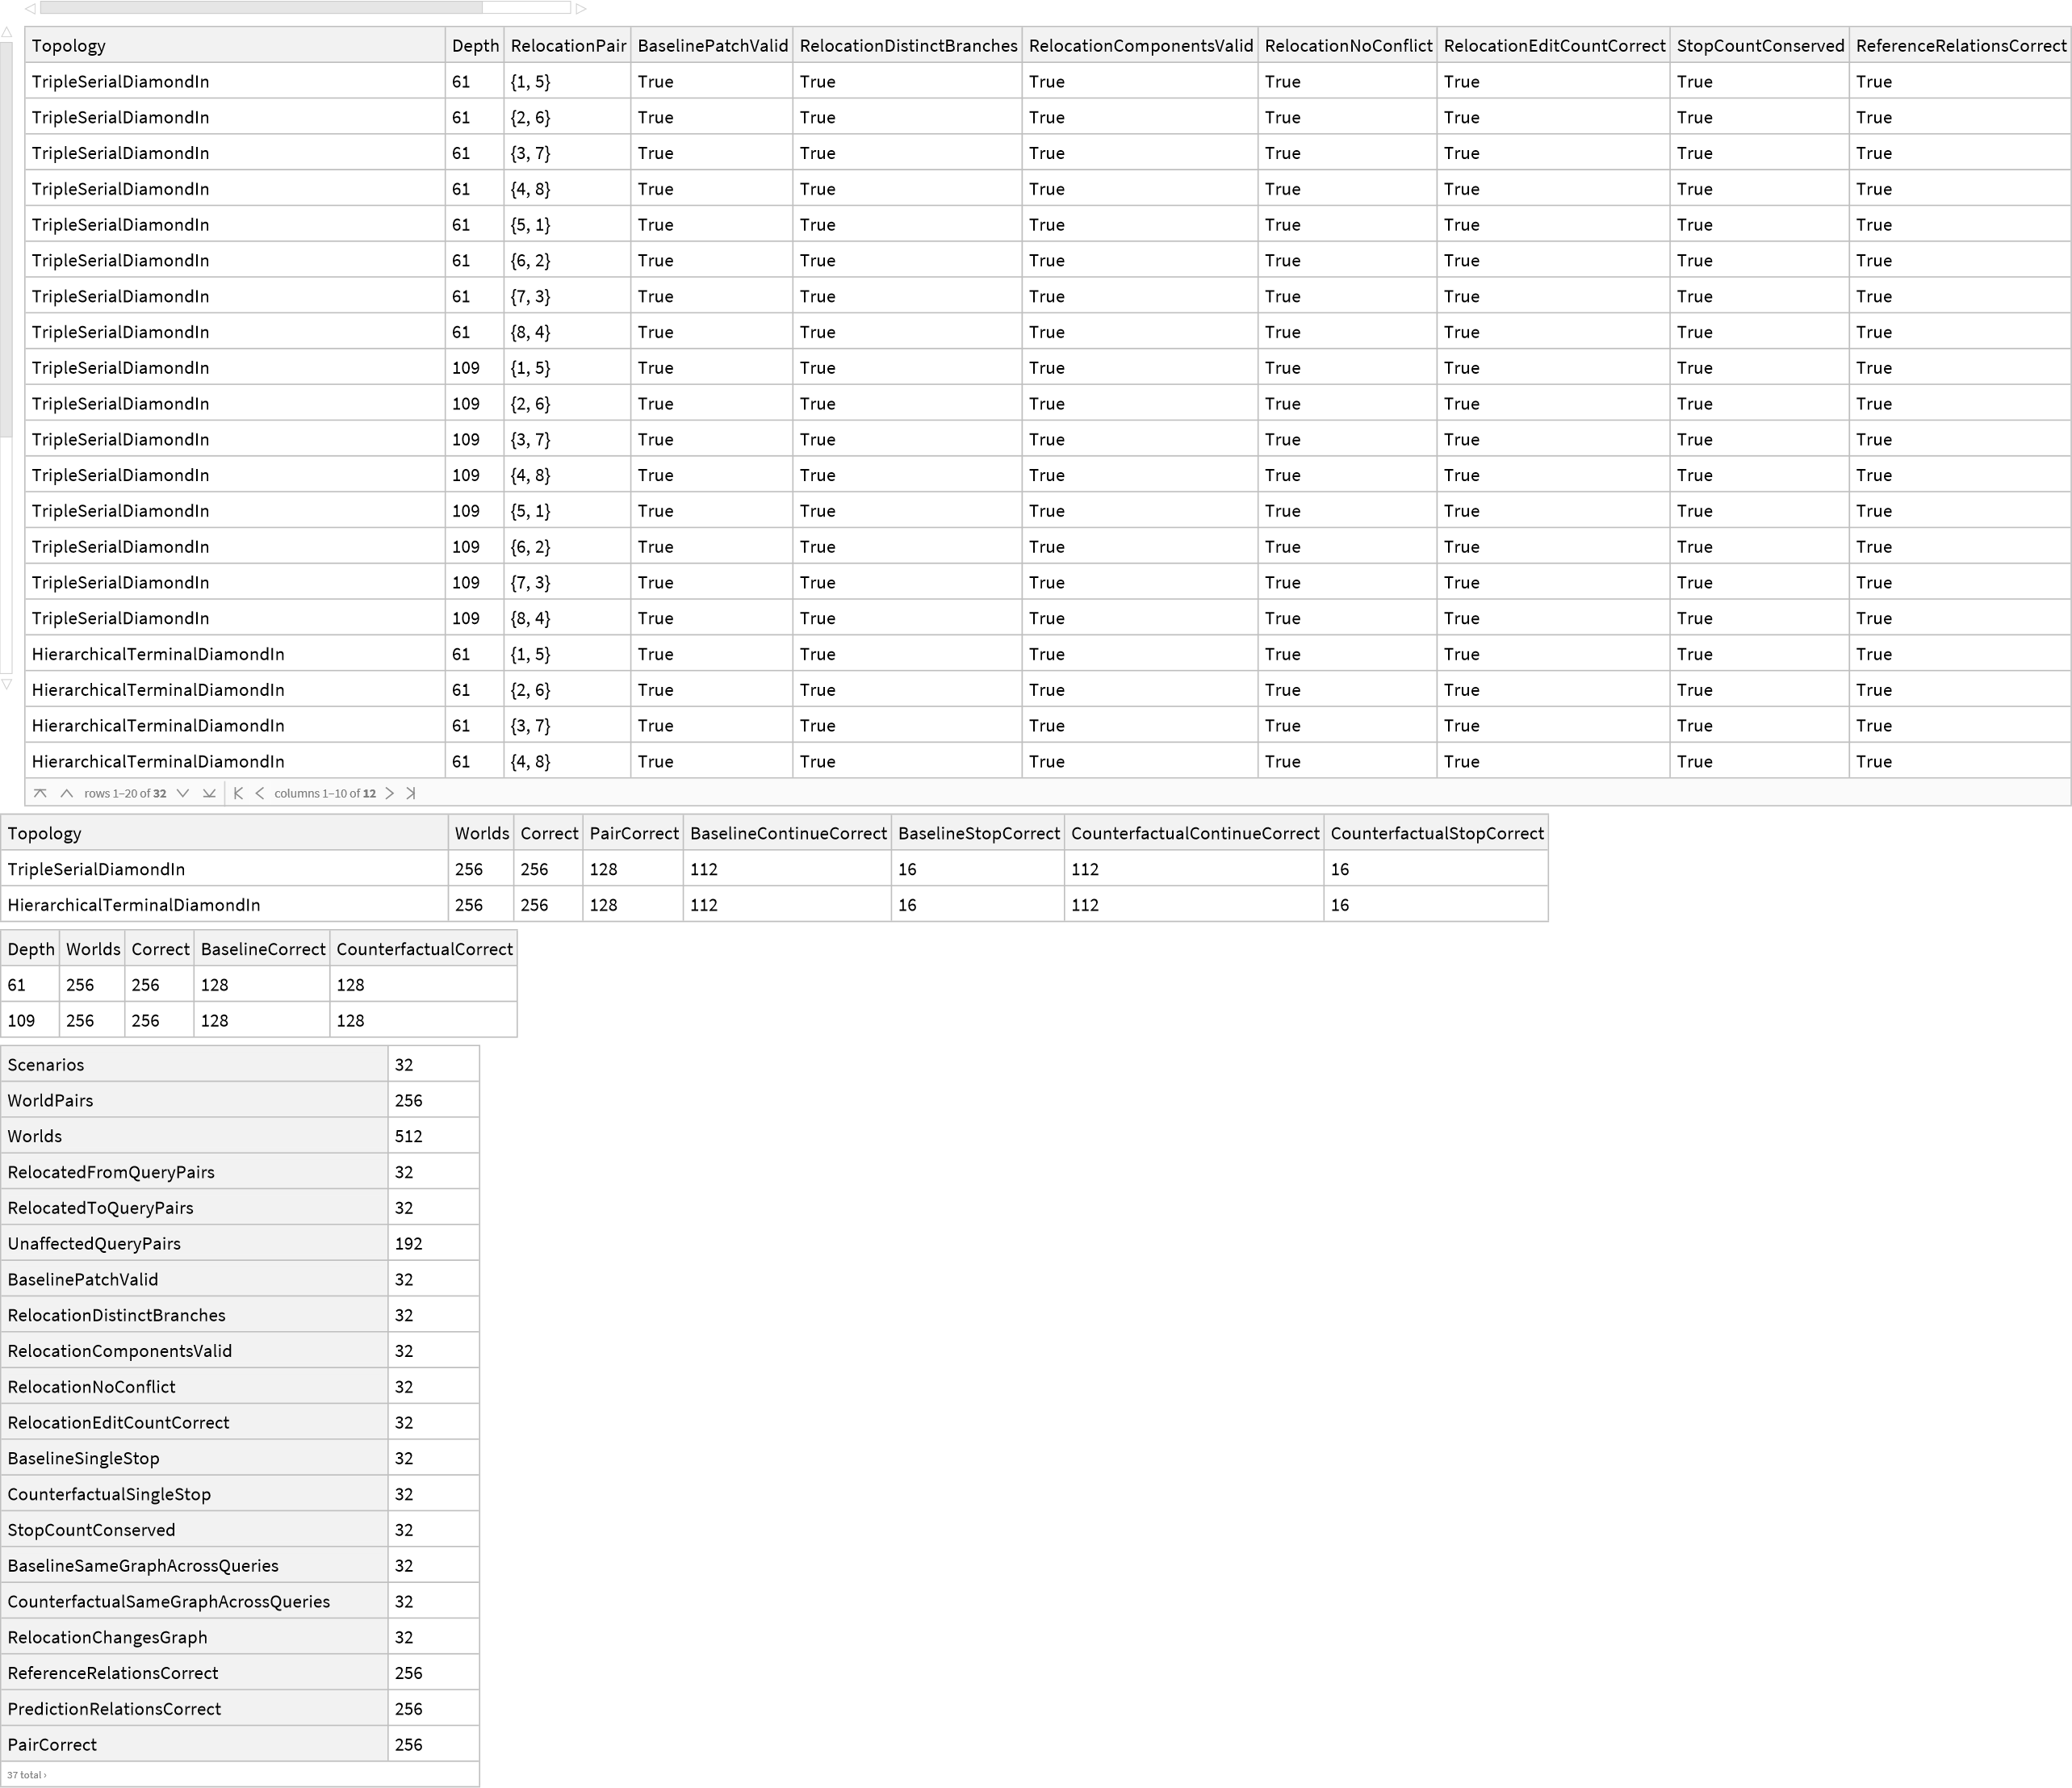

In [167]:
blindScenarios89=Flatten[
Table[
PrepareScenario89[topology,depth,relocationPair],
{topology,blindTopologies89},
{depth,blindDepths89},
{relocationPair,blindRelocationPairs89}
],
2
];

blindWorldPairs89=Flatten[Lookup[blindScenarios89,"WorldPairs"],1];
baselineWorlds89=Flatten[Lookup[blindScenarios89,"BaselineWorlds"],1];
counterfactualWorlds89=Flatten[
Lookup[blindScenarios89,"CounterfactualWorlds"],1
];
blindWorlds89=Join[baselineWorlds89,counterfactualWorlds89];

summary89=<|
"Scenarios"->Length[blindScenarios89],
"WorldPairs"->Length[blindWorldPairs89],
"Worlds"->Length[blindWorlds89],
"RelocatedFromQueryPairs"->Count[
blindWorldPairs89,p_/;TrueQ[p["RelocatedFromQuery"]]
],
"RelocatedToQueryPairs"->Count[
blindWorldPairs89,p_/;TrueQ[p["RelocatedToQuery"]]
],
"UnaffectedQueryPairs"->Count[
blindWorldPairs89,p_/;TrueQ[p["UnaffectedQuery"]]
],
"BaselinePatchValid"->Count[
blindScenarios89,s_/;TrueQ[s["BaselinePatchValid"]]
],
"RelocationDistinctBranches"->Count[
blindScenarios89,s_/;TrueQ[s["RelocationDistinctBranches"]]
],
"RelocationComponentsValid"->Count[
blindScenarios89,s_/;TrueQ[s["RelocationComponentsValid"]]
],
"RelocationNoConflict"->Count[
blindScenarios89,s_/;TrueQ[s["RelocationNoConflict"]]
],
"RelocationEditCountCorrect"->Count[
blindScenarios89,s_/;TrueQ[s["RelocationEditCountCorrect"]]
],
"BaselineSingleStop"->Count[
blindScenarios89,s_/;TrueQ[s["BaselineSingleStop"]]
],
"CounterfactualSingleStop"->Count[
blindScenarios89,s_/;TrueQ[s["CounterfactualSingleStop"]]
],
"StopCountConserved"->Count[
blindScenarios89,s_/;TrueQ[s["StopCountConserved"]]
],
"BaselineSameGraphAcrossQueries"->Count[
blindScenarios89,s_/;TrueQ[s["BaselineSameGraphAcrossQueries"]]
],
"CounterfactualSameGraphAcrossQueries"->Count[
blindScenarios89,s_/;TrueQ[s["CounterfactualSameGraphAcrossQueries"]]
],
"RelocationChangesGraph"->Count[
blindScenarios89,s_/;TrueQ[s["RelocationChangesGraph"]]
],
"ReferenceRelationsCorrect"->Count[
blindWorldPairs89,p_/;TrueQ[p["ReferenceRelationCorrect"]]
],
"PredictionRelationsCorrect"->Count[
blindWorldPairs89,p_/;TrueQ[p["PredictionRelationCorrect"]]
],
"PairCorrect"->Count[blindWorldPairs89,p_/;TrueQ[p["PairCorrect"]]],
"ScenarioPerfect"->Count[
blindScenarios89,s_/;TrueQ[s["AllSixteenWorldsCorrect"]]
],
"BaselineContinueCorrect"->Count[
baselineWorlds89,w_/;SameQ[w["Target"],"Continue"]&&TrueQ[w["Correct"]]
],
"BaselineStopCorrect"->Count[
baselineWorlds89,w_/;SameQ[w["Target"],"Stop"]&&TrueQ[w["Correct"]]
],
"CounterfactualContinueCorrect"->Count[
counterfactualWorlds89,w_/;SameQ[w["Target"],"Continue"]&&TrueQ[w["Correct"]]
],
"CounterfactualStopCorrect"->Count[
counterfactualWorlds89,w_/;SameQ[w["Target"],"Stop"]&&TrueQ[w["Correct"]]
],
"WorldCorrect"->Count[blindWorlds89,w_/;TrueQ[w["Correct"]]],
"CanonicalCaseExactlyBase"->Count[
blindWorlds89,w_/;TrueQ[w["CanonicalCaseExactlyBase"]]
],
"ContractionCountCorrect"->Count[
blindWorlds89,w_/;TrueQ[w["ContractionCountCorrect"]]
],
"ProtectedNodesPreserved"->Count[
blindWorlds89,w_/;TrueQ[w["ProtectedNodesPreserved"]]
],
"ReferenceActionsCorrect"->Count[
blindWorlds89,w_/;SameQ[w["ReferenceAction"],w["Target"]]
],
"NonEmptyTokens"->Count[blindWorlds89,w_/;w["RawTokenCount"]>0],
"ValidFeatureVectors"->Count[
blindWorlds89,w_/;VectorQ[w["FeatureVector"],IntegerQ]&&
Length[w["FeatureVector"]]===27
],
"PredictionFailures"->Count[
blindWorlds89,w_/;SameQ[w["Prediction"],$Failed]
],
"TerminatedNaturally"->Count[
blindWorlds89,w_/;TrueQ[w["TerminatedNaturally"]]
],
"HitSafetyCap"->Count[blindWorlds89,w_/;TrueQ[w["HitSafetyCap"]]],
"EightBranchWorlds"->Count[
blindWorlds89,w_/;SameQ[w["BranchCount"],8]
],
"TotalTraceSeconds"->Total@Lookup[blindWorlds89,"TraceSeconds"]
|>;

byTopology89=Map[
Function[topology,
Module[{worlds,pairs,baseline,counterfactual},
worlds=Select[blindWorlds89,SameQ[#1["Topology"],topology]&];
pairs=Select[blindWorldPairs89,
SameQ[#1["BaselineWorld"]["Topology"],topology]&];
baseline=Select[worlds,SameQ[#1["GraphCondition"],"SingleStopBaseline"]&];
counterfactual=Select[
worlds,SameQ[#1["GraphCondition"],"StopRelocatedCounterfactual"]&
];
<|
"Topology"->topology,
"Worlds"->Length[worlds],
"Correct"->Count[worlds,w_/;TrueQ[w["Correct"]]],
"PairCorrect"->Count[pairs,p_/;TrueQ[p["PairCorrect"]]],
"BaselineContinueCorrect"->Count[
baseline,w_/;SameQ[w["Target"],"Continue"]&&TrueQ[w["Correct"]]
],
"BaselineStopCorrect"->Count[
baseline,w_/;SameQ[w["Target"],"Stop"]&&TrueQ[w["Correct"]]
],
"CounterfactualContinueCorrect"->Count[
counterfactual,w_/;SameQ[w["Target"],"Continue"]&&TrueQ[w["Correct"]]
],
"CounterfactualStopCorrect"->Count[
counterfactual,w_/;SameQ[w["Target"],"Stop"]&&TrueQ[w["Correct"]]
]
|>
]
],
blindTopologies89
];

byDepth89=Map[
Function[depth,
Module[{worlds,baseline,counterfactual},
worlds=Select[blindWorlds89,SameQ[#1["Depth"],depth]&];
baseline=Select[worlds,SameQ[#1["GraphCondition"],"SingleStopBaseline"]&];
counterfactual=Select[
worlds,SameQ[#1["GraphCondition"],"StopRelocatedCounterfactual"]&
];
<|
"Depth"->depth,
"Worlds"->Length[worlds],
"Correct"->Count[worlds,w_/;TrueQ[w["Correct"]]],
"BaselineCorrect"->Count[baseline,w_/;TrueQ[w["Correct"]]],
"CounterfactualCorrect"->Count[
counterfactual,w_/;TrueQ[w["Correct"]]
]
|>
]
],
blindDepths89
];

Column[{
Dataset[Map[
KeyTake[#,{"Topology","Depth","RelocationPair",
"BaselinePatchValid","RelocationDistinctBranches",
"RelocationComponentsValid","RelocationNoConflict",
"RelocationEditCountCorrect","StopCountConserved",
"ReferenceRelationsCorrect","PredictionRelationsCorrect",
"AllSixteenWorldsCorrect"}]&,
blindScenarios89
]],
Dataset[byTopology89],
Dataset[byDepth89],
Dataset[{summary89}]
}]


Dataset[{<|Stage -> S89, Name -> StopRelocationCounterfactualBlind, 
 
>     CandidateHash -> 703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     CandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, 
 
>     S88CheckpointFileHash -> 
 
>      1c56bb0a87eba871f8474a93d4206d6aebbf1d66412a0d3927e62155a81e2fa4, 
 
>     ProtocolHash -> 32f425daed5c9604a2971de24b763360b14f0c64cddd3e08fc0d1cfa9de9b846, 
 
>     TestDefinitionHash -> 
 
>      c78b29923c011330697a70e628f5c53410c5c46dcb0cd36908002a008f8fd7f5, 
 
>     Depths -> {61, 109}, Topologies -> 
 
>      {TripleSerialDiamondIn, HierarchicalTerminalDiamondIn}, 
 
>     RelocationPairs -> 
 
>      {{1, 5}, {2, 6}, {3, 7}, {4, 8}, {5, 1}, {6, 2}, {7, 3}, {8, 4}}, 
 
>     Scenarios -> 32, WorldPairs -> 256, Worlds -> 512, BaselineContinueCorrect -> 224, 
 
>     BaselineStopCorrect -> 32, CounterfactualContinueCorrect -> 224, 
 
>     CounterfactualStopCorrect -> 32, WorldCorrect -> 512, Accuracy -> 1., 
 
>     BalancedAccuracy -> 1., PairCorrect -> 256, PredictionRelationsCorrect -> 256, 
 
>     ScenarioPerfect -> 32, OriginalFrozenModelChanged -> False, 
 
>     OriginalK33CandidateChanged -> False, FrozenDecoderChanged -> False, 
 
>     CoreChanged -> False, CanonicalizerChanged -> False, 
 
>     InterventionCoreChanged -> False, TopologyPrimitivesChanged -> False, 
 
>     FeatureRuntimeChanged -> False, TestDefinitionChangedDuringRun -> False, 
 
>     ProtocolChangedDuringRun -> False, DeduplicationMechanismChanged -> False, 
 
>     ObservationAggregationChanged -> False, S88CheckpointChanged -> False, 
 
>     TestValidityPassed -> True, BlindPerfect -> True, 
 
>     CandidateFrozenBeforeS89 -> True, BlindProtocolHashedBeforeCases -> True, 
 
>     S87DDecoderUsed -> True, S88CheckpointLocked -> True, TrainingRun -> False, 
 
>     CandidateSearchRun -> False, DecoderEditApplied -> False, 
 
>     RetuningApplied -> False, HistoricalBlindTestsRerun -> False, 
 
>     AllEightQueryPositionsTestedPerGraph -> True, 
 
>     SameQueryBeforeAfterIntervention -> True, StopCountConservedBeforeAfter -> True, 
 
>     S89IsBlindCounterfactualRelocationTest -> True, 
 
>     MayClaimBlindStopRelocationTransfer -> True, 
 
>     MayClaimGeneralCounterfactualReasoning -> False, MayClaimCausalDiscovery -> False, 
 
>     TotalTraceSeconds -> 669.602, 
 
>     BlindResultHash -> 
 
>      90d5b918f72020d1a58bf39f0d1a222ec94464221932899ba975361b523facf8, 
 
>     Outcome -> S89_BLIND_STOP_RELOCATION_PASS, 
 
>     SuggestedNextStage -> S90_INTERVENTION_ALGEBRA_BLIND|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 58], 
 
>    1], <||>]
Dataset[{<|CertificateExported -> True, 
 
>     CertificatePath -> E:/engine_wolf/TCCT_S89_BlindResultCertificate.json, 
 
>     CertificateFileHash -> 
 
>      7d0f543f6f17384ee8969131547b2766aad1fbaed999e5b039c2708d6d89b032|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{CertificateExported, CertificatePath, 
 
>      CertificateFileHash}, {TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[String]}], 1], <||>]
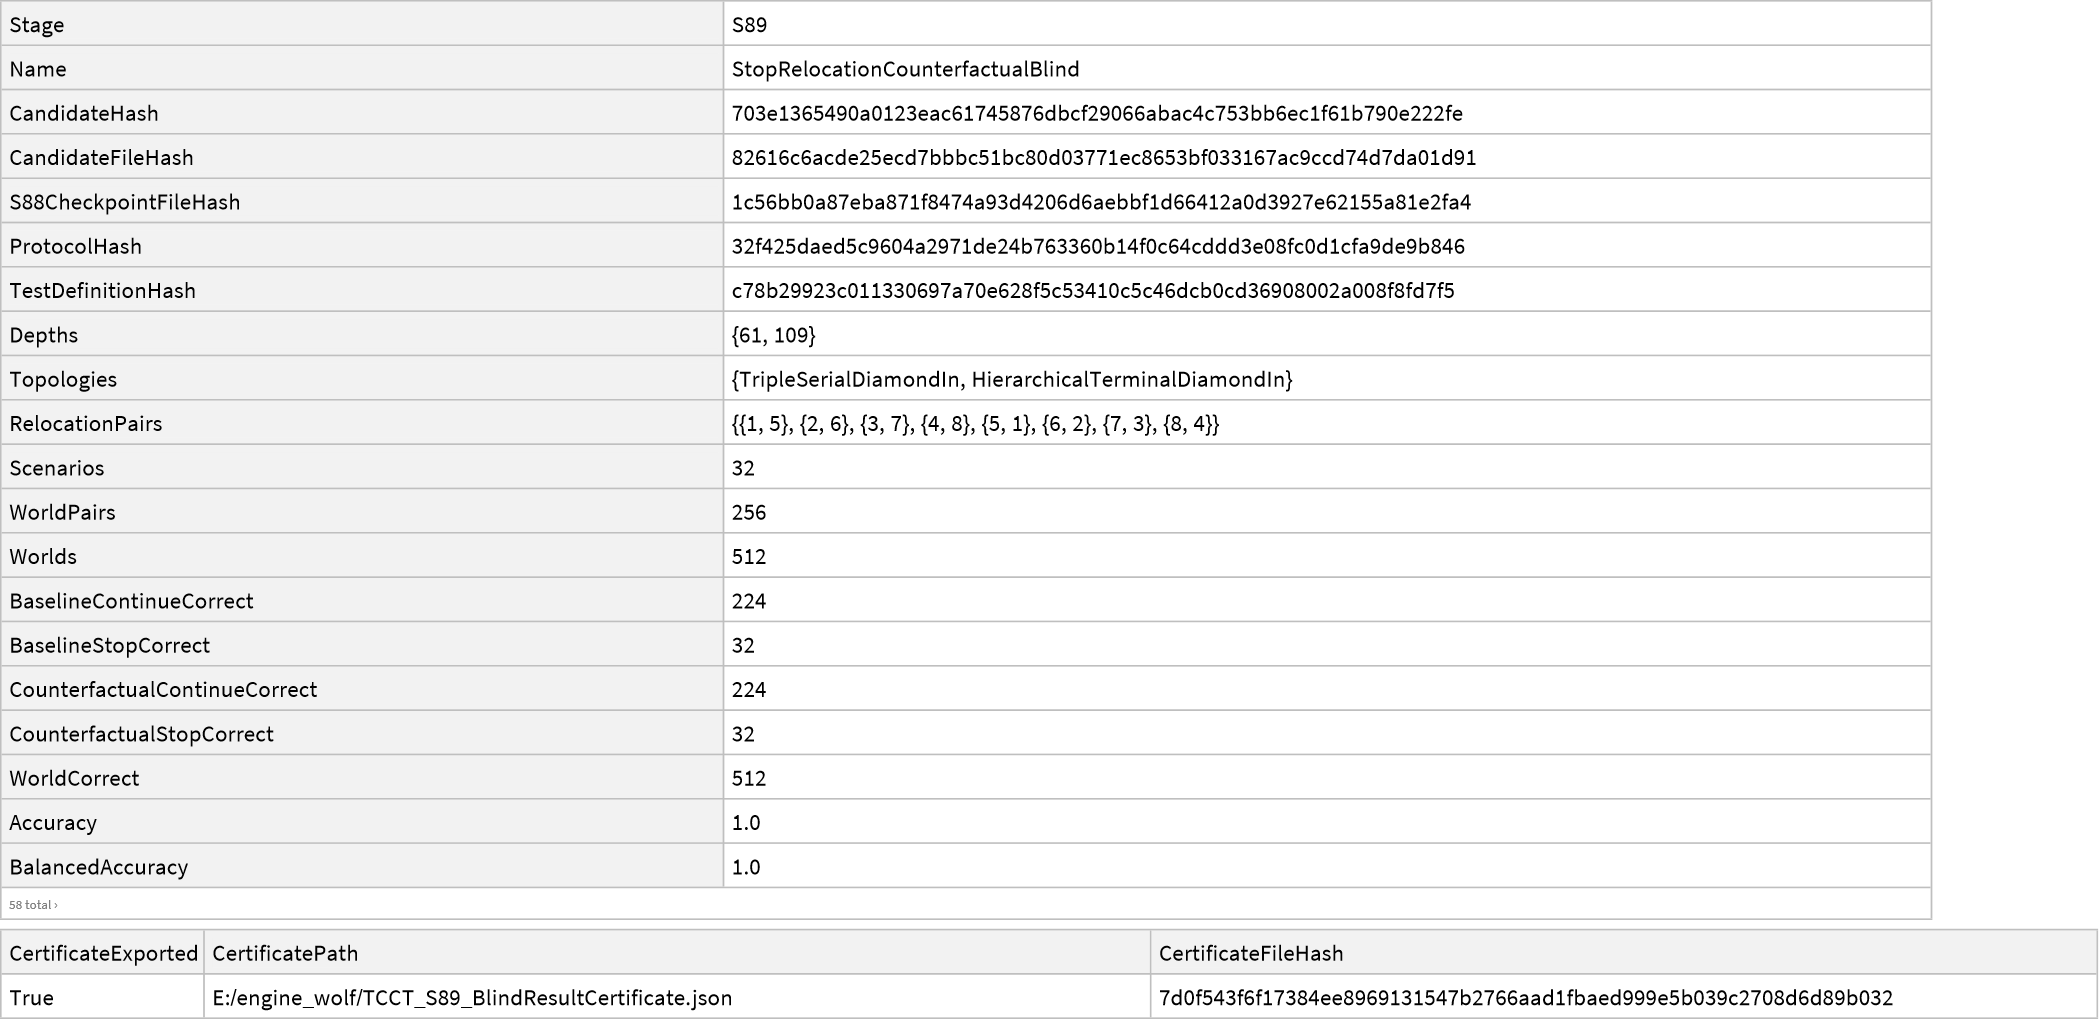

In [176]:
modelHashAfter89=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashAfter89=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
decoderObjectHashAfter89=Hash[
Normal[KeyDrop[frozenDecoderLoaded89,{"Classifier"}]],"SHA256","HexString"
];
coreHashAfter89=Hash[CoreDefinitionBundle89[],"SHA256","HexString"];
canonicalizerHashAfter89=Hash[
{DownValues[FindPrivateDiamond79B],DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]},"SHA256","HexString"
];
interventionHashAfter89=Hash[
{DownValues[LocalMediatorSources82],DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],DownValues[ReferenceAction82]},
"SHA256","HexString"
];
topologyPrimitiveHashAfter89=Hash[
{DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],
DownValues[HierarchicalDiamondIn80]},"SHA256","HexString"
];
decoderRuntimeDefinitionHashAfter89=Hash[
TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"
];
testDefinitionHashAfter89=Hash[S89TestDefinitionBundle[],"SHA256","HexString"];
protocolHashAfter89=Hash[Normal[protocol89],"SHA256","HexString"];

k33CandidateFileHashAfter89=FileSHA256Hex89[k33CandidatePath89];
decoderRuntimeFileHashAfter89=FileSHA256Hex89[decoderRuntimePath89];
decoderCandidateFileHashAfter89=FileSHA256Hex89[decoderCandidatePath89];
freezeCertificateFileHashAfter89=FileSHA256Hex89[freezeCertificatePath89];
s88CheckpointFileHashAfter89=FileSHA256Hex89[s88CheckpointPath89];

originalFrozenModelUnchanged89=SameQ[
modelHashBefore89,modelHashAfter89,expectedFrozenModelHash89
];
k33CandidateUnchanged89=And[
SameQ[k33ObjectHashBefore89,k33ObjectHashAfter89],
SameQ[k33ObjectHashAfter89,expectedK33CandidateHash89],
SameQ[k33CandidateFileHashBefore89,k33CandidateFileHashAfter89],
SameQ[k33CandidateFileHashAfter89,expectedK33CandidateFileHash89]
];
frozenDecoderUnchanged89=And[
SameQ[decoderObjectHashBefore89,decoderObjectHashAfter89],
SameQ[decoderCandidateHashLoaded89,expectedDecoderCandidateHash89],
SameQ[decoderCandidateFileHashBefore89,decoderCandidateFileHashAfter89],
SameQ[decoderCandidateFileHashAfter89,expectedDecoderCandidateFileHash89]
];
coreUnchanged89=SameQ[coreHashBefore89,coreHashAfter89];
canonicalizerUnchanged89=SameQ[canonicalizerHashBefore89,canonicalizerHashAfter89];
interventionCoreUnchanged89=SameQ[interventionHashBefore89,interventionHashAfter89];
topologyPrimitivesUnchanged89=SameQ[
topologyPrimitiveHashBefore89,topologyPrimitiveHashAfter89
];
decoderRuntimeUnchanged89=And[
SameQ[decoderRuntimeDefinitionHashBefore89,decoderRuntimeDefinitionHashAfter89],
SameQ[decoderRuntimeFileHashBefore89,decoderRuntimeFileHashAfter89],
SameQ[decoderRuntimeFileHashAfter89,expectedFeatureRuntimeFileHash89]
];
testDefinitionUnchanged89=SameQ[
testDefinitionHashBefore89,testDefinitionHashAfter89
];
protocolUnchanged89=SameQ[protocolHash89,protocolHashAfter89];
freezeCertificateUnchanged89=And[
SameQ[freezeCertificateFileHashBefore89,freezeCertificateFileHashAfter89],
SameQ[freezeCertificateFileHashAfter89,expectedFreezeCertificateFileHash89]
];
s88CheckpointUnchanged89=And[
SameQ[s88CheckpointFileHashBefore89,s88CheckpointFileHashAfter89],
SameQ[s88CheckpointFileHashAfter89,expectedS88CheckpointFileHash89]
];
observationAggregationUnchanged89=SameQ[
protocol89["ObservationAggregation"],
"FullQueriedObservationMultisetWithoutCodeDeduplication"
];

testValidityPassed89=And[
TrueQ[preflightPassed89],
TrueQ[originalFrozenModelUnchanged89],
TrueQ[k33CandidateUnchanged89],
TrueQ[frozenDecoderUnchanged89],
TrueQ[coreUnchanged89],
TrueQ[canonicalizerUnchanged89],
TrueQ[interventionCoreUnchanged89],
TrueQ[topologyPrimitivesUnchanged89],
TrueQ[decoderRuntimeUnchanged89],
TrueQ[testDefinitionUnchanged89],
TrueQ[protocolUnchanged89],
TrueQ[freezeCertificateUnchanged89],
TrueQ[s88CheckpointUnchanged89],
TrueQ[observationAggregationUnchanged89],
TrueQ[protocol89["NoCaseEvaluatedBeforeProtocolHash"]],
SameQ[summary89["Scenarios"],32],
SameQ[summary89["WorldPairs"],256],
SameQ[summary89["Worlds"],512],
SameQ[summary89["RelocatedFromQueryPairs"],32],
SameQ[summary89["RelocatedToQueryPairs"],32],
SameQ[summary89["UnaffectedQueryPairs"],192],
SameQ[summary89["BaselinePatchValid"],32],
SameQ[summary89["RelocationDistinctBranches"],32],
SameQ[summary89["RelocationComponentsValid"],32],
SameQ[summary89["RelocationNoConflict"],32],
SameQ[summary89["RelocationEditCountCorrect"],32],
SameQ[summary89["BaselineSingleStop"],32],
SameQ[summary89["CounterfactualSingleStop"],32],
SameQ[summary89["StopCountConserved"],32],
SameQ[summary89["BaselineSameGraphAcrossQueries"],32],
SameQ[summary89["CounterfactualSameGraphAcrossQueries"],32],
SameQ[summary89["RelocationChangesGraph"],32],
SameQ[summary89["ReferenceRelationsCorrect"],256],
SameQ[summary89["CanonicalCaseExactlyBase"],512],
SameQ[summary89["ContractionCountCorrect"],512],
SameQ[summary89["ProtectedNodesPreserved"],512],
SameQ[summary89["ReferenceActionsCorrect"],512],
SameQ[summary89["NonEmptyTokens"],512],
SameQ[summary89["ValidFeatureVectors"],512],
SameQ[summary89["PredictionFailures"],0],
SameQ[summary89["TerminatedNaturally"],512],
SameQ[summary89["HitSafetyCap"],0],
SameQ[summary89["EightBranchWorlds"],512]
];

blindPerfect89=And[
TrueQ[testValidityPassed89],
SameQ[summary89["BaselineContinueCorrect"],224],
SameQ[summary89["BaselineStopCorrect"],32],
SameQ[summary89["CounterfactualContinueCorrect"],224],
SameQ[summary89["CounterfactualStopCorrect"],32],
SameQ[summary89["WorldCorrect"],512],
SameQ[summary89["PairCorrect"],256],
SameQ[summary89["PredictionRelationsCorrect"],256],
SameQ[summary89["ScenarioPerfect"],32]
];

continueCases89=448;
stopCases89=64;
continueCorrect89=summary89["BaselineContinueCorrect"]+
summary89["CounterfactualContinueCorrect"];
stopCorrect89=summary89["BaselineStopCorrect"]+
summary89["CounterfactualStopCorrect"];
accuracy89=N[summary89["WorldCorrect"]/512];
balancedAccuracy89=N@Mean[{
continueCorrect89/continueCases89,stopCorrect89/stopCases89
}];

resultPayload89=<|
"Stage"->"S89",
"Name"->"StopRelocationCounterfactualBlind",
"CandidateHash"->decoderCandidateHashLoaded89,
"CandidateFileHash"->decoderCandidateFileHashAfter89,
"S88CheckpointFileHash"->s88CheckpointFileHashAfter89,
"ProtocolHash"->protocolHashAfter89,
"TestDefinitionHash"->testDefinitionHashAfter89,
"Depths"->blindDepths89,
"Topologies"->blindTopologies89,
"RelocationPairs"->blindRelocationPairs89,
"Scenarios"->summary89["Scenarios"],
"WorldPairs"->summary89["WorldPairs"],
"Worlds"->summary89["Worlds"],
"BaselineContinueCorrect"->summary89["BaselineContinueCorrect"],
"BaselineStopCorrect"->summary89["BaselineStopCorrect"],
"CounterfactualContinueCorrect"->summary89["CounterfactualContinueCorrect"],
"CounterfactualStopCorrect"->summary89["CounterfactualStopCorrect"],
"WorldCorrect"->summary89["WorldCorrect"],
"Accuracy"->accuracy89,
"BalancedAccuracy"->balancedAccuracy89,
"PairCorrect"->summary89["PairCorrect"],
"PredictionRelationsCorrect"->summary89["PredictionRelationsCorrect"],
"ScenarioPerfect"->summary89["ScenarioPerfect"],
"OriginalFrozenModelChanged"->!TrueQ[originalFrozenModelUnchanged89],
"OriginalK33CandidateChanged"->!TrueQ[k33CandidateUnchanged89],
"FrozenDecoderChanged"->!TrueQ[frozenDecoderUnchanged89],
"CoreChanged"->!TrueQ[coreUnchanged89],
"CanonicalizerChanged"->!TrueQ[canonicalizerUnchanged89],
"InterventionCoreChanged"->!TrueQ[interventionCoreUnchanged89],
"TopologyPrimitivesChanged"->!TrueQ[topologyPrimitivesUnchanged89],
"FeatureRuntimeChanged"->!TrueQ[decoderRuntimeUnchanged89],
"TestDefinitionChangedDuringRun"->!TrueQ[testDefinitionUnchanged89],
"ProtocolChangedDuringRun"->!TrueQ[protocolUnchanged89],
"DeduplicationMechanismChanged"->!TrueQ[coreUnchanged89],
"ObservationAggregationChanged"->!TrueQ[observationAggregationUnchanged89],
"S88CheckpointChanged"->!TrueQ[s88CheckpointUnchanged89],
"TestValidityPassed"->testValidityPassed89,
"BlindPerfect"->blindPerfect89
|>;

blindResultHash89=Hash[Normal[resultPayload89],"SHA256","HexString"];

cert89=Join[resultPayload89,<|
"CandidateFrozenBeforeS89"->True,
"BlindProtocolHashedBeforeCases"->True,
"S87DDecoderUsed"->True,
"S88CheckpointLocked"->True,
"TrainingRun"->False,
"CandidateSearchRun"->False,
"DecoderEditApplied"->False,
"RetuningApplied"->False,
"HistoricalBlindTestsRerun"->False,
"AllEightQueryPositionsTestedPerGraph"->True,
"SameQueryBeforeAfterIntervention"->True,
"StopCountConservedBeforeAfter"->True,
"S89IsBlindCounterfactualRelocationTest"->True,
"MayClaimBlindStopRelocationTransfer"->blindPerfect89,
"MayClaimGeneralCounterfactualReasoning"->False,
"MayClaimCausalDiscovery"->False,
"TotalTraceSeconds"->summary89["TotalTraceSeconds"],
"BlindResultHash"->blindResultHash89,
"Outcome"->Which[
!TrueQ[testValidityPassed89],"INVALID_S89_BLIND_TEST",
TrueQ[blindPerfect89],"S89_BLIND_STOP_RELOCATION_PASS",
True,"S89_VALID_BLIND_FAILURE_DO_NOT_RETUNE"
],
"SuggestedNextStage"->Which[
!TrueQ[testValidityPassed89],"S89R_REPAIR_HARNESS_WITHOUT_MODEL_CHANGE",
TrueQ[blindPerfect89],"S90_INTERVENTION_ALGEBRA_BLIND",
True,"S89A_FAILURE_AUDIT_WITHOUT_RETUNING"
]
|>];

certificateExportResult89=Quiet@Check[
Export[s89ResultCertificatePath,cert89,"RawJSON"],$Failed
];
certificateExported89=And[
StringQ[certificateExportResult89],FileExistsQ[s89ResultCertificatePath]
];

Column[{
Dataset[{cert89}],
Dataset[{<|
"CertificateExported"->certificateExported89,
"CertificatePath"->s89ResultCertificatePath,
"CertificateFileHash"->If[
certificateExported89,FileSHA256Hex89[s89ResultCertificatePath],Missing[]
]
|>}]
}]
